In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Teorie

      S (Susceptible - Náchylní): Zdraví jedinci, kteří mohou nemoc chytit
      I (Infectious - Infekční): Nemocní jedinci, kteří ji mohou šířit dál
      R (Recovered/Removed - Uzdravení/Odstranění): Lidé, kteří nemoc prodělali a získali imunitu (nebo zemřeli). Nemohou se znovu nakazit ani nemoc šířit.

      beta: Míra přenosu (infekčnost) - vyjadřuje pravděpodobnost, že se náchylný člověk nakazí při kontaktu s infekčním
      gamma: Míra uzdravení - Vypočítá se jako převrácená hodnota průměrné doby trvání infekce (1/D, kde D jsou dny). Pokud jsi infekční průměrně 5 dní, gamma je 1/5
      R_0 (Základní reprodukční číslo): Udává průměrný počet lidí, které nakazí jeden nemocný ve zcela zdravé populaci. Platí vztah R_0 = beta/gamma.
      D: průměrná doba infekčnosti v dnech, kolik průměrně dní může člověk nakazit ostatní

      --rovnice
      změna počtu náchylných S
      S˙ = -βSI / N
      Počet náchylných (S) klesá. Rychlost poklesu závisí na tom, jak moc se potkávají zdraví a nemocní (S*I), vztaženo na celou populaci (N), a na tom, jak je nemoc nakažlivá (β).

      změna počtu infekčních I
      I˙ = βSI / N - γI
      Počet nemocných (I) roste o ty, kteří se nově nakazili (první člen, stejný jako nahoře, ale kladný), a klesá o ty, kteří se uzdravili (γI).

      změna počtu uzdravených R
      R˙ = γI
      Počet uzdravených (R) roste přímo úměrně tomu, kolik je aktuálně nemocných a jak rychle se uzdravují.

In [1]:
# 1. Definice diferenciálních rovnic SIR modelu
def sir_model(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

In [3]:
# 2. Nastavení počátečních podmínek
N = 100000  # Celková populace (např. 100 tisíc obyvatel)
I0 = 1      # Na začátku máme 1 infikovaného jedince
R0_pop = 0  # Počet uzdravených na začátku je 0
S0 = N - I0 - R0_pop  # Zbytek populace je náchylný k infekci

# Vytvoření časové osy (simulujeme 250 dní s krokem 1 den)
t = np.linspace(0, 250, 250)

In [4]:
# 3. Slovník vybraných nemocí (název: [R0, Doba infekčnosti D])
diseases = {
    "Chřipka": [3.5, 5],
    "Spalničky": [17.0, 8],
    "Černý kašel": [17.0, 21],
    "Plané neštovice": [11.0, 7],
    "Zarděnky": [6.5, 14]
}

Simulace probíhá pro populaci velikosti N = 100000 jedinců, počátek 1 infikovaný.

--- CHŘIPKA (R0 = 3.5) ---
1. Vrchol epidemie: den 25 (přibližně 35635 aktuálně nemocných)
2. Délka trvání epidemie: 89 dní
3. Celkem onemocní: 96598 lidí | Zůstane zdravých: 3401 lidí

--- SPALNIČKY (R0 = 17.0) ---
1. Vrchol epidemie: den 7 (přibližně 77097 aktuálně nemocných)
2. Délka trvání epidemie: 98 dní
3. Celkem onemocní: 99999 lidí | Zůstane zdravých: 0 lidí

--- ČERNÝ KAŠEL (R0 = 17.0) ---
1. Vrchol epidemie: den 19 (přibližně 77439 aktuálně nemocných)
2. Délka trvání epidemie: >250
3. Celkem onemocní: 99999 lidí | Zůstane zdravých: 0 lidí

--- PLANÉ NEŠTOVICE (R0 = 11.0) ---
1. Vrchol epidemie: den 10 (přibližně 68831 aktuálně nemocných)
2. Délka trvání epidemie: 89 dní
3. Celkem onemocní: 99998 lidí | Zůstane zdravých: 1 lidí

--- ZARDĚNKY (R0 = 6.5) ---
1. Vrchol epidemie: den 34 (přibližně 55818 aktuálně nemocných)
2. Délka trvání epidemie: 194 dní
3. Celkem onemocní: 99848 lidí | Zůstane z

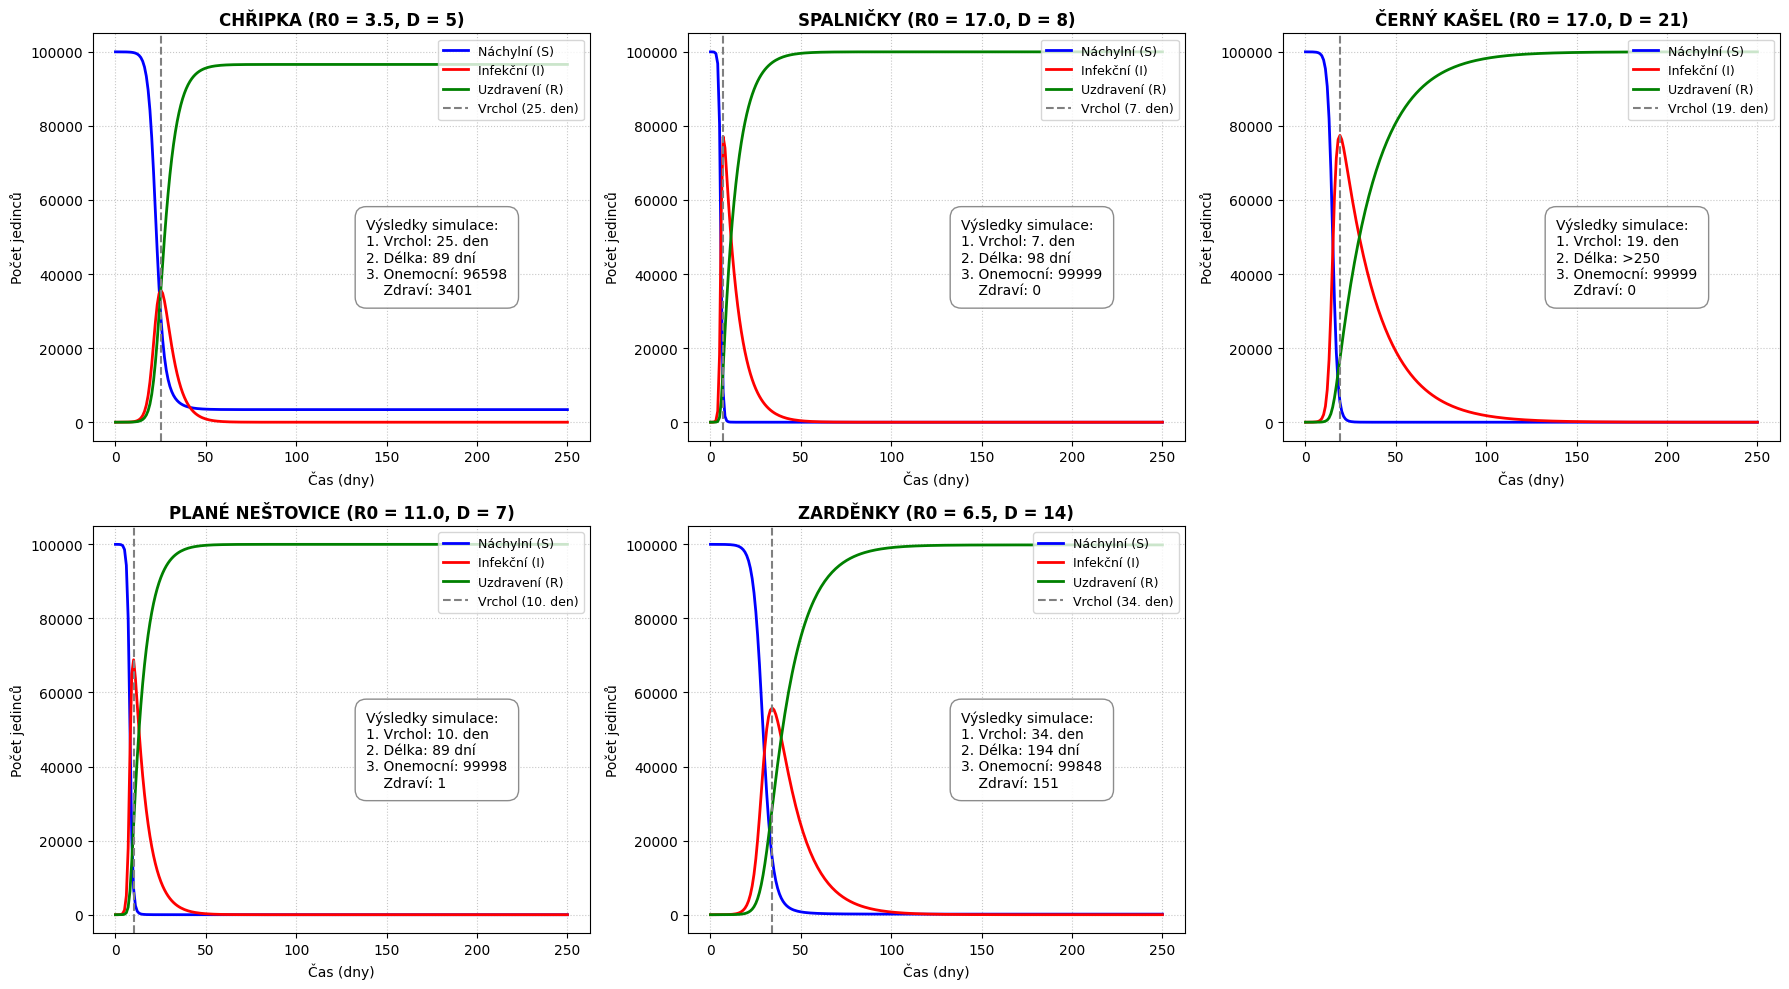

In [5]:
# 4. Spuštění simulace pro každou nemoc
print(f"Simulace probíhá pro populaci velikosti N = {N} jedinců, počátek 1 infikovaný.\n")

# --- PŘÍPRAVA HLAVNÍHO OKNA (MŘÍŽKY) ---
# Vytvoříme okno (fig) a mřížku grafů (axes) se 2 řádky a 3 sloupci
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

# axes.flatten() převede 2D mřížku na jednoduchý seznam (0 až 5), aby se nám tím dobře procházelo
axes_flat = axes.flatten()

for i, (name, params) in enumerate(diseases.items()):
    R_naught = params[0]
    D = params[1]

    # Výpočet parametrů beta a gamma
    gamma = 1.0 / D
    beta = R_naught * gamma

    # Počáteční vektor
    y0 = S0, I0, R0_pop

    # Řešení soustavy ODE (Ordinary Differential Equations) pomocí scipy
    ret = odeint(sir_model, y0, t, args=(N, beta, gamma)) # 4 sloupce - dny, S, I, R
    S, I, R = ret.T  # Transpozice a rozbalení výsledků -> všechny výsledky S v jednom řádku, ...

    # --- ODPOVĚDI NA OTÁZKY ---

    # 1. Kdy dojde k vrcholu epidemie? (Hledáme index maximální hodnoty I)
    peak_day_index = np.argmax(I) #najde index dne kdy bylo nejvíce nakažených
    peak_day = t[peak_day_index] #najde den podle indexu
    max_infected = I[peak_day_index] #zjistí kolik ten den bylo nakažených

    # 2. Jak dlouho epidemie potrvá?
    # Za konec epidemie považujeme moment (po vrcholu), kdy počet infekčních klesne pod 1
    post_peak_I = I[peak_day_index:] #vezmeme seznam počtu nakažených od vrcholu do konce
    post_peak_t = t[peak_day_index:] #vezme seznam dnů po vrcholu do konce
    # Najdeme první den, kdy I < 1
    end_indices = np.where(post_peak_I < 1.0)[0] #všechny pozice kde je nakažených lidí < 1 (vrací tuple, musím přidat [0])
    if len(end_indices) > 0: #pokud jsme našli nějaký den kdy nakažení klesli pod 1, tak vezmeme první den ze seznamu
        duration = post_peak_t[end_indices[0]]
        # Číslo zformátujeme přímo zde
        duration_text = f"{duration:.0f} dní" #linespace nevytváří celá čísla, odstranění desetiných míst (pro výpočty jistější float)
    else: #epidemie ještě neskončila, nenašli jsme den kdy klesli < 1
        duration_text = ">250" # Pokud epidemie neskončí do 250 dní

    # 3. Kolik jedinců nakonec onemocní a kolik ne?
    # R na konci simulace představuje celkový počet lidí, kteří si nemocí prošli
    # S na konci představuje lidi, kteří nikdy neonemocněli
    total_infected = R[-1] + I[-1] #poslední číslo imuních a nakažených -> suma všech co nemoc prodělali
    total_uninfected = S[-1] #všichni kdo na konci zůstali ve skupině náchylní nemoc neprodělali

    print(f"--- {name.upper()} (R0 = {R_naught}) ---")
    print(f"1. Vrchol epidemie: den {peak_day:.0f} (přibližně {int(max_infected)} aktuálně nemocných)")
    print(f"2. Délka trvání epidemie: {duration_text}")
    print(f"3. Celkem onemocní: {int(total_infected)} lidí | Zůstane zdravých: {int(total_uninfected)} lidí\n")

    # --- VYKRESLENÍ DO KONKRÉTNÍHO PODGRAFU ---
    # Vybereme chlívek v mřížce podle pořadového čísla 'i'
    ax = axes_flat[i]

    #jednotlivé kategorie jako line graf
    ax.plot(t, S, label='Náchylní (S)', color='blue', linewidth=2)
    ax.plot(t, I, label='Infekční (I)', color='red', linewidth=2)
    ax.plot(t, R, label='Uzdravení (R)', color='green', linewidth=2)

    #šedý ukazatel vrcholu epidemie
    ax.axvline(x=peak_day, color='gray', linestyle='--', label=f'Vrchol ({peak_day:.0f}. den)')

    # Vložení textu s výsledky
    text_odpovedi = (
        f"Výsledky simulace:\n"
        f"1. Vrchol: {peak_day:.0f}. den\n"
        f"2. Délka: {duration_text}\n"
        f"3. Onemocní: {int(total_infected)}\n"
        f"    Zdraví: {int(total_uninfected)}"
    )

    # Souřadnice pro text v rámci jednoho malého grafu
    ax.text(0.55, 0.45, text_odpovedi, transform=ax.transAxes, # kam dát rámeček, co vypsat, bere velikost grafu od 0 do 1
             fontsize=10, verticalalignment='center', #velikost a vycentrování textu
             bbox=dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor='gray', alpha=0.9)) #jak se zobrazuje krabička - zaoblené rohy, barva pozadí a ohraničení, průhlednost

    # Názvy os a titulky (u ax. používáme ax.set_title místo plt.title atd.)
    ax.set_title(f'{name.upper()} (R0 = {R_naught}, D = {D})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Čas (dny)', fontsize=10)
    ax.set_ylabel('Počet jedinců', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.7)

# --- DOKONČOVACÍ PRÁCE S MŘÍŽKOU ---
# Máme 6 chlívků, ale jen 5 nemocí. Šestý chlívek (index 5) tedy vypneme (skryjeme osy a rámeček).
axes_flat[5].axis('off')

# Tento příkaz zajistí, že se grafy nebudou navzájem překrývat (udělá mezi nimi hezké mezery)
plt.tight_layout()

# Zobrazení celého velkého okna se všemi 5 grafy
plt.show()

# Otázky
    1. Kdy dojde k vrcholu epidemie?
    - Nejvíce nemocných

    Chřipka - 25. den
    Spalničky - 7. den
    Černý kašel - 19. den
    Plané neštovice -10. den
    Zarděnky - 34. den

    2. Jak dlouho epidemie potrvá?
    - první bod kdy počet nemocných klesne pod 1

    Chřipka - 89 dní
    Spalničky - 98 dní
    Černý kašel - >250 dní
    Plané neštovice - 89 dní
    Zarděnky - 194 dní

    3. Kolik jedinců nakonec onemocní a kolik ne?
    - závěrečný počet infikovaných a uzdravených / náchylných

    onemocnění / zdraví
    Chřipka - 96598/3401
    Spalničky - 99999/0
    Černý kašel - 99999/0
    Plané neštovice - 99998/1
    Zarděnky - 99848/151